In [ ]:
%pip install langgraph langchain_mistralai python-dotenv

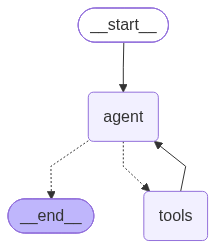

In [ ]:
import json
from typing import Literal
from dotenv import load_dotenv
from IPython.display import Image
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_mistralai import ChatMistralAI
from langgraph.graph import END, START, MessagesState, StateGraph

load_dotenv()

@tool
def adder(x: int, y: int) -> int:
    """Returns the sum of 2 integers."""
    return x + y

tools = [adder]
tools_by_name = {tool.name: tool for tool in tools}
llm = ChatMistralAI(model="zai-glm-5-2")
llm_with_tools = llm.bind_tools(tools)

def ask_llm(state: MessagesState) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": response}

def execute_tool(state: MessagesState) -> dict:
    last_message = state["messages"][-1]
    tool_outputs = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_call_id = tool_call["id"]

        selected_tool = tools_by_name[tool_name]
        observation = selected_tool.invoke(tool_args)

        tool_outputs.append(
            ToolMessage(
                content=json.dumps(observation),
                tool_call_id=tool_call_id,
                name=tool_name,
            )
        )

    return {"messages": tool_outputs}

def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tools"
    return END

workflow = StateGraph(MessagesState)
workflow.add_node("agent", ask_llm)
workflow.add_node("tools", execute_tool)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")
app = workflow.compile()
Image(app.get_graph().draw_mermaid_png())

In [7]:
# 5. Execute agent
response = app.invoke(
    {"messages": HumanMessage(content="What is 42 plus 58? After getting the result, add 77")}
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is 42 plus 58? After getting the result, add 77
================================== Ai Message ==================================

I'll start by adding 42 and 58 together:
Tool Calls:
  adder (chatcmpl-tool-bbc6f818b3db0f2c)
 Call ID: chatcmpl-tool-bbc6f818b3db0f2c
  Args:
    x: 42
    y: 58
================================= Tool Message =================================
Name: adder

100
================================== Ai Message ==================================

The result of 42 + 58 is **100**. Now let me add 77 to that result:
Tool Calls:
  adder (chatcmpl-tool-ad8fdb9f6b5679ca)
 Call ID: chatcmpl-tool-ad8fdb9f6b5679ca
  Args:
    x: 100
    y: 77
================================= Tool Message =================================
Name: adder

177
================================== Ai Message ==================================

Here are the results:

1. **42 + 58 = 100**
2. **100 + 77 = 177**

So

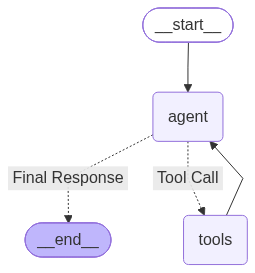

In [ ]:
# Variant with str instead of literal
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_mistralai import ChatMistralAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from typing import Literal

# 1. Setup environment and model
load_dotenv()

@tool
def adder(x: int, y: int) -> int:
    """Returns the sum of 2 integers."""
    return x + y

tools = [adder]

llm = ChatMistralAI(model="mistral-small-latest").bind_tools(tools)
llm_with_tools = llm.bind_tools(tools)


# 2. Define node function
def ask_llm(state: MessagesState) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": response}


# 3. Define conditional router edge

def should_continue(state: MessagesState) -> str:
    messages = state["messages"]
    last_message = messages[-1]

    # If the model produced a tool call, route to the tool node
    if last_message.tool_calls:
        return "Tool Call"
    # Otherwise, stop and return final answer
    return "Final Response"


# 4. Build graph
workflow = StateGraph(MessagesState)
workflow.add_node("agent", ask_llm)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"Tool Call": "tools", "Final Response": END}) # NEW
workflow.add_edge("tools", "agent")

# Compile graph
app = workflow.compile()

# The labels show on the edge as long as they are different from the node names
Image(app.get_graph().draw_mermaid_png())

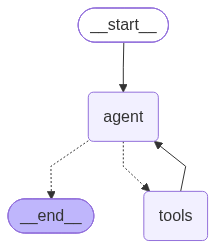

In [18]:
# Final version: pre-built edge

from dotenv import load_dotenv
from langchain_core.tools import tool
from langchain_mistralai import ChatMistralAI
from langgraph.graph import START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition # NEW

# 1. Setup environment and model
load_dotenv()

@tool
def adder(x: int, y: int) -> int:
    """Returns the sum of 2 integers."""
    return x + y

tools = [adder]

llm = ChatMistralAI(model="mistral-small-latest").bind_tools(tools)
llm_with_tools = llm.bind_tools(tools)


# 2. Define node function
def ask_llm(state: MessagesState) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": response}


# 4. Build graph
workflow = StateGraph(MessagesState)
workflow.add_node("agent", ask_llm)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition) # NEW
workflow.add_edge("tools", "agent")

# Compile graph
# The labels show on the edge as long as they are different from the node names
app = workflow.compile()
Image(app.get_graph().draw_mermaid_png())